# T69 — K-Pg impact winter: ocean biogeochemistry collapse and recovery

**Cluster J: Paleoclimate.**  *Dataset:* cGENIE Earth System Model K-Pg boundary experiments (Ying et al. 2026, CC BY 4.0) — ocean biogeochemistry (BioGeM) output from a 10 kyr late-Maastrichtian spinup, a 100-year impact-winter crisis run (combined solar dimming + CO2 forcing + dust/iron deposition), a 5 kyr Danian recovery continuation, and single-mechanism sensitivity experiments.

The Cretaceous-Paleogene (K-Pg) boundary, 66 million years ago, is the best-documented mass extinction in Earth history — a >10 km asteroid impact at Chicxulub triggered a cascade of environmental crises (impact-winter darkness and cooling, then CO2-driven warming, ocean acidification, and a collapse of marine primary production) on timescales from days to millennia. cGENIE, a coarse-resolution Earth-system model of intermediate complexity, has been run through this event with all three major forcings (solar dimming, CO2 release, dust/iron deposition) coupled together, giving a physically self-consistent picture of *how fast* and *how severe* the ocean's response was — and, via single-mechanism sensitivity runs, *which forcing did the most damage*.

## What this notebook produces

1. **§2 — Late-Maastrichtian baseline.** Pre-impact steady-state maps of sea-surface temperature, surface pH, and calcite saturation state (Ω_cal) on cGENIE's own late-Cretaceous paleogeography.
2. **§3 — GPlately-reconstructed 66 Ma paleogeography, for comparison.** A `gplately`/Scotese & Wright (2018) reconstruction of modern coastlines to 66 Ma, shown alongside cGENIE's own boundary-condition coastline — cGENIE's default paleogeography is itself built on the Scotese & Wright model, so this panel is a consistency check (does `gplately`'s reconstruction of the same model agree with the grid cGENIE actually ran on?) rather than an independent-model comparison.
3. **§4 — The crisis: before/after anomaly maps.** ΔSST, ΔpH, and ΔΩ_cal between the pre-impact baseline and two points in the 100-yr crisis run (immediately post-impact and 100 years later).
4. **§5 — Global-mean time series through crisis + recovery.** Ocean temperature, surface pH, POC export production, and dissolved O2, stitched across the spin-up → crisis → 5,000-year Danian recovery.
5. **§6 — Forcing decomposition.** Compares the combined-forcing `main` run against `solar`-only, `CO2`-only, and a `noextinction` control, to show which mechanism (darkness vs warming/acidification vs biotic collapse itself) drives most of the post-impact anomaly.

## Learning objectives

- Load and slice a multi-experiment, multi-timestep cGENIE NetCDF bundle with `xarray`.
- Render an Earth-system-model field on its own native (non-uniform, paleogeography-specific) ocean grid with `pygmt`, using the model's own land-sea mask as the coastline rather than a mismatched external one, and overlay a matching `gplately`-reconstructed continent fill so land areas never render as blank/NaN.
- Use `gplately` to reconstruct modern coastlines to a deep-time age with the same plate model that produced cGENIE's own boundary condition, and understand why this makes the overlay geographically consistent with the grid it sits on.
- Read and plot ASCII global-mean time series output from an Earth-system model.
- Use a single-mechanism sensitivity-experiment design to attribute an observed change to one of several simultaneous forcings.

## Prerequisites and runtime

- **Plate model**: Scotese & Wright (2018) — the same paleogeography cGENIE's own late-Cretaceous boundary condition is built on (cGENIE's documentation does not name this model explicitly, but the continental configuration matches it). Used for the §3 comparison reconstruction and as the continent-outline overlay on every map in §2/§4.
- **Data (bundled, git-tracked)**: `data/cgenie_kpg_ying2026/` (1.1 MB) — a compact, derived subset of Ying et al. (2026)'s cGENIE K-Pg archive (CC BY 4.0). See `data/cgenie_kpg_ying2026/README.md` for full provenance, derivation method, and a pointer to the complete original archive on Zenodo.
- **Python**: `gplately`, `pygmt`, `pygplates`, `xarray`, `numpy`, `pandas`.
- **Runtime**: ~30 s.


## Environment + imports

In [1]:
from pathlib import Path
import os, sys, warnings
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import xarray as xr
import pygmt
import gplately
import pygplates
from plate_model_manager import PlateModelManager

sys.path.insert(0, str(Path("Notebooks").resolve()))
from paleoclimate_helpers import refine_for_plot

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, xr, pygmt, gplately, pygplates):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', getattr(_m, 'version', 'n/a'))}")


Environment
  python      3.11.15
  numpy       2.4.4
  pandas      3.0.2
  xarray      2026.7.0
  pygmt       v0.17.0
  gplately    2.0.0
  pygplates   1.0.0


## Configuration

In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME       = "scotese_and_wright2018"  # the plate model cGENIE's own K-Pg paleogeography is built on
RECON_AGE_MA     = 66.0              # K-Pg boundary age

DATA_DIR         = Path("data/cgenie_kpg_ying2026")
SNAPSHOTS_NC     = DATA_DIR / "kpg_biogeochem_snapshots.nc"
TIMESERIES_CSV   = DATA_DIR / "kpg_global_timeseries.csv"

REGION           = "d"               # global
PROJ             = "N16c"             # Robinson

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


## 1. Load the compact cGENIE K-Pg bundle

In [3]:
snapshots = xr.open_dataset(SNAPSHOTS_NC)
timeseries = pd.read_csv(TIMESERIES_CSV)

print(f"  {len(snapshots['exp'])} (experiment, time) snapshots on a {snapshots.dims['lat']}x{snapshots.dims['lon']} grid")
print(f"  fields: {[v for v in snapshots.data_vars if v not in ('grid_mask','grid_area','grid_topo')]}")
print(f"  global-mean time series: {timeseries['experiment'].unique().tolist()} x {timeseries['variable'].unique().tolist()}")


  34 (experiment, time) snapshots on a 36x36 grid
  fields: ['ocn_sur_temp', 'misc_pH', 'carb_sur_ohm_cal', 'carb_sur_ohm_arg', 'bio_fexport_POC', 'phys_fxsw', 'ocn_sur_PO4']
  global-mean time series: ['SPIN', 'main', 'Danian', 'solar', 'CO2', 'size_effect', 'noextinction'] x ['ocn_temp', 'surpH', 'fexport_POC', 'ocn_O2', 'ocn_ALK']


/tmp/ipykernel_21503/11454757.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.


## 2. Late-Maastrichtian baseline — pre-impact ocean state

Three fields from the 10 kyr spin-up's final (steady-state) time slice, on cGENIE's own late-Cretaceous paleogeography and land-sea mask. This is the "normal" world the impact disrupts. A `gplately`/Scotese & Wright (2018) continent fill is drawn underneath each field so land areas show as solid ground rather than blank/NaN, with cGENIE's own land-sea mask contoured on top in black for the exact grid boundary the model actually used.

grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


grdcontour [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


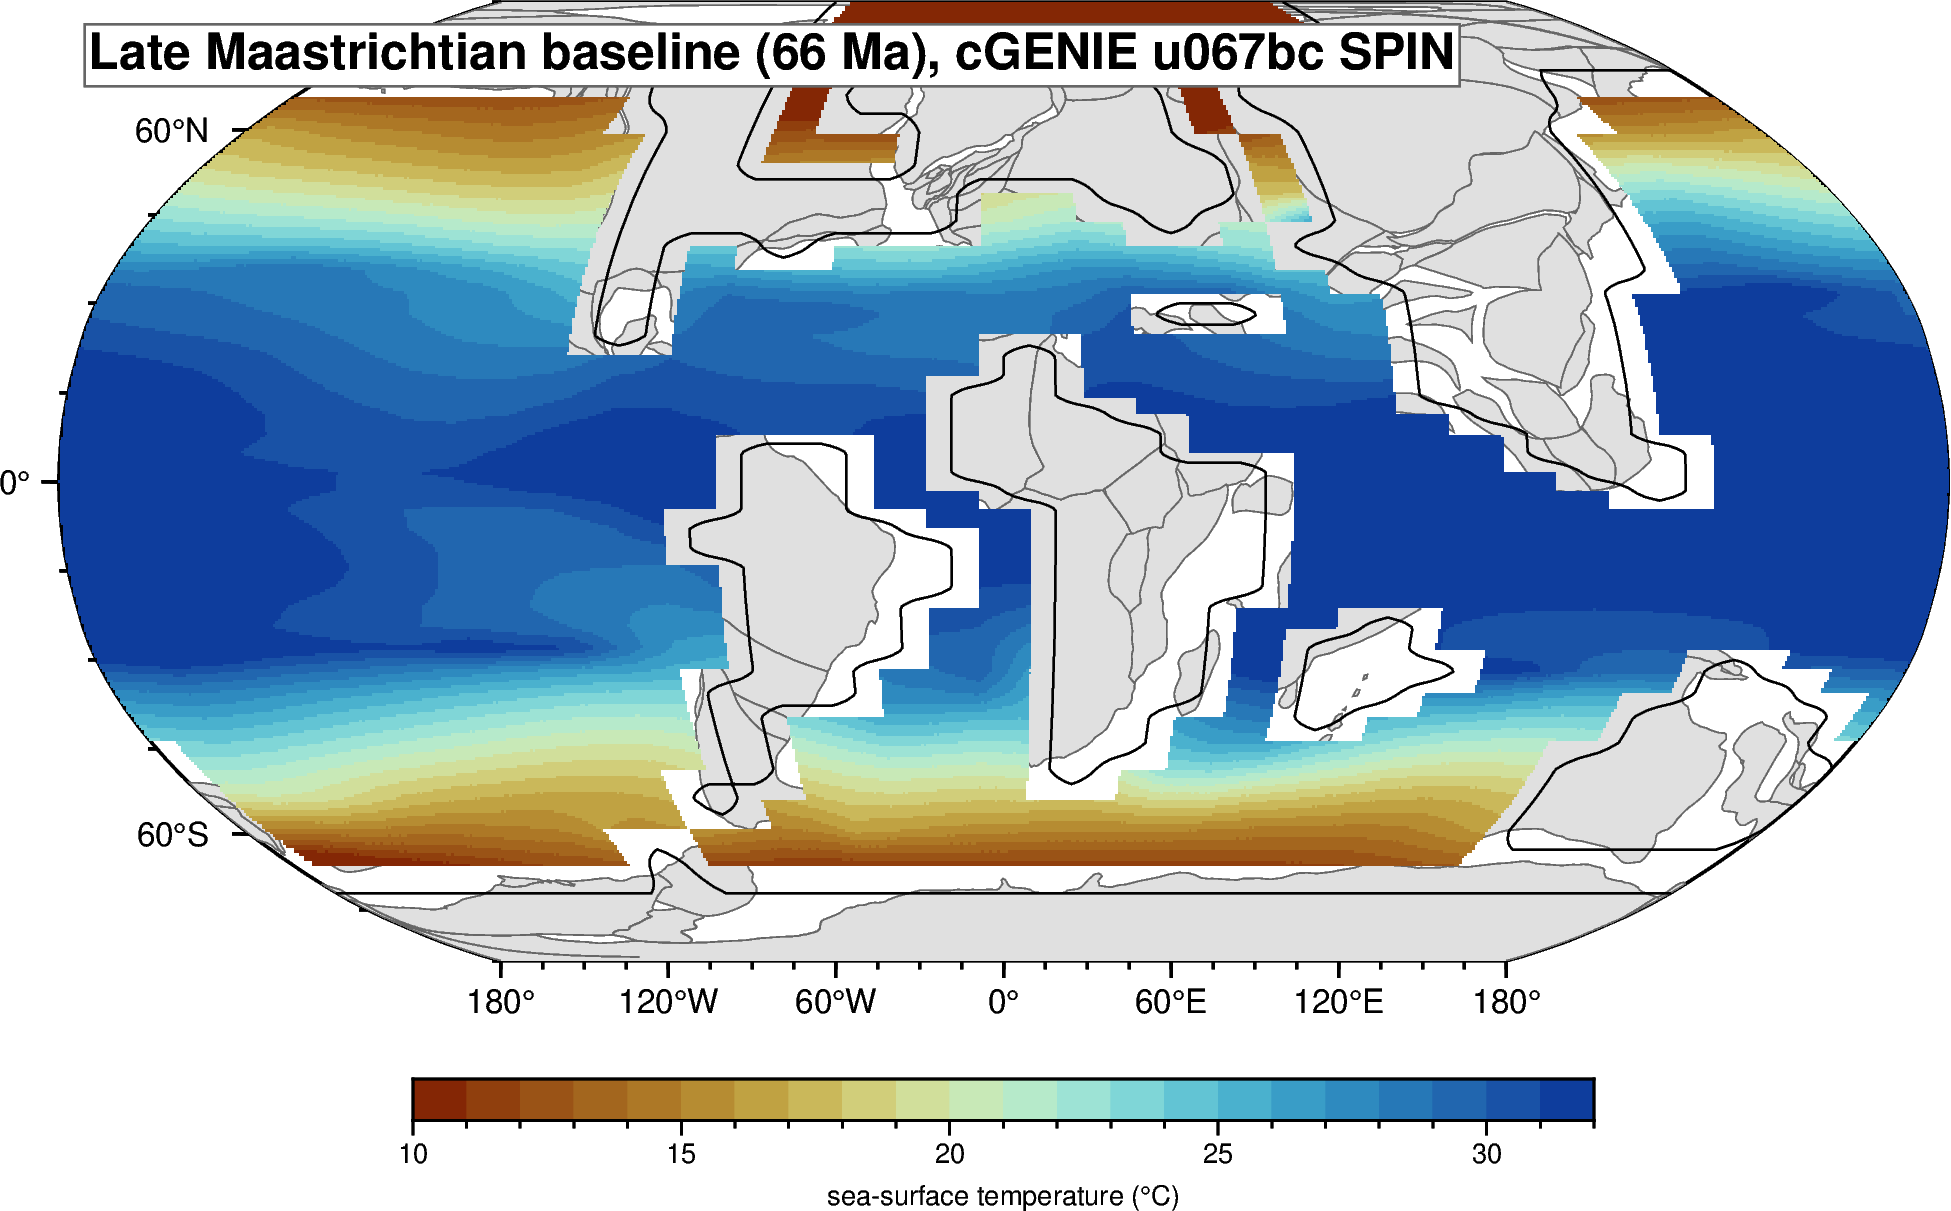

grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


grdcontour [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


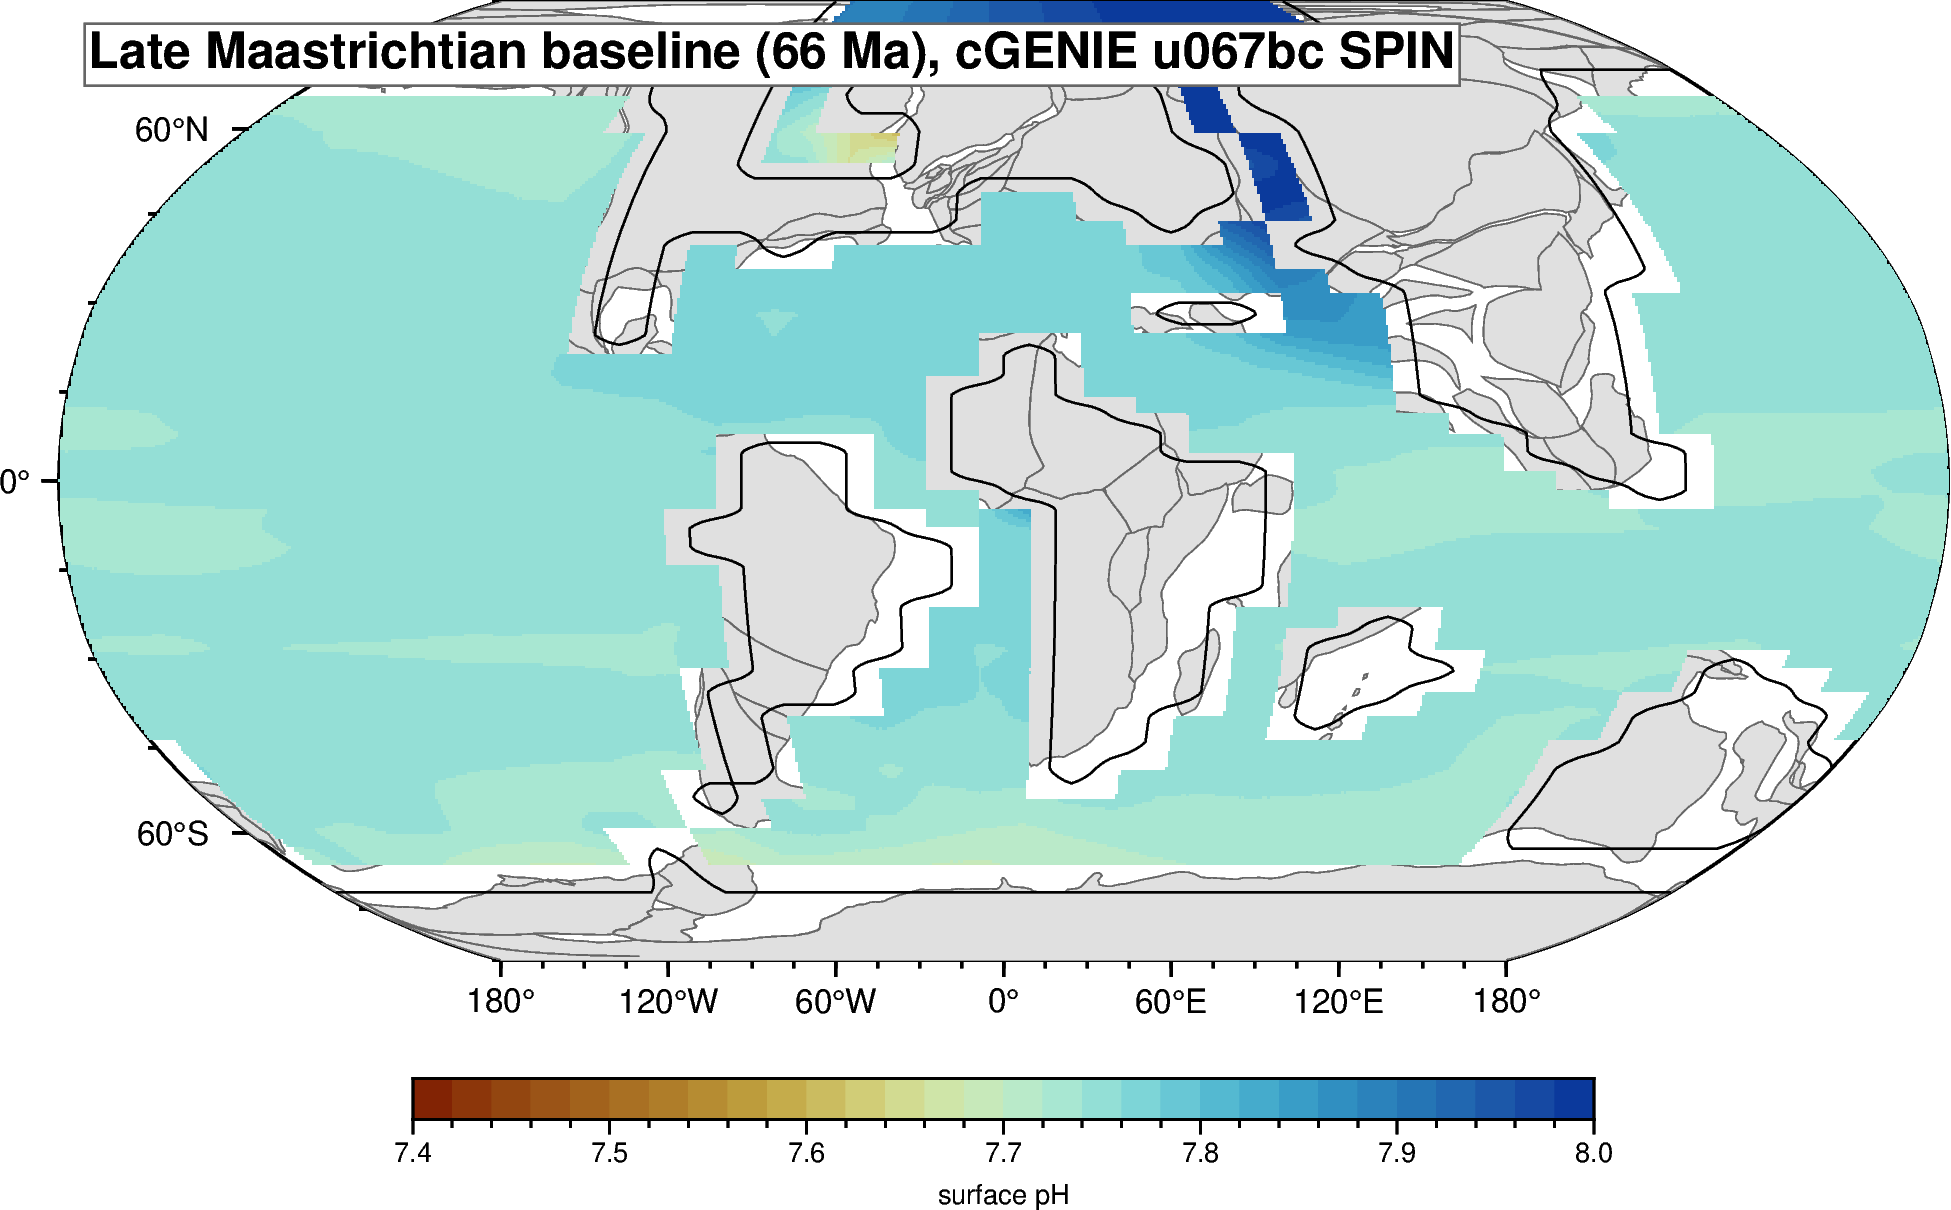

grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


grdcontour [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


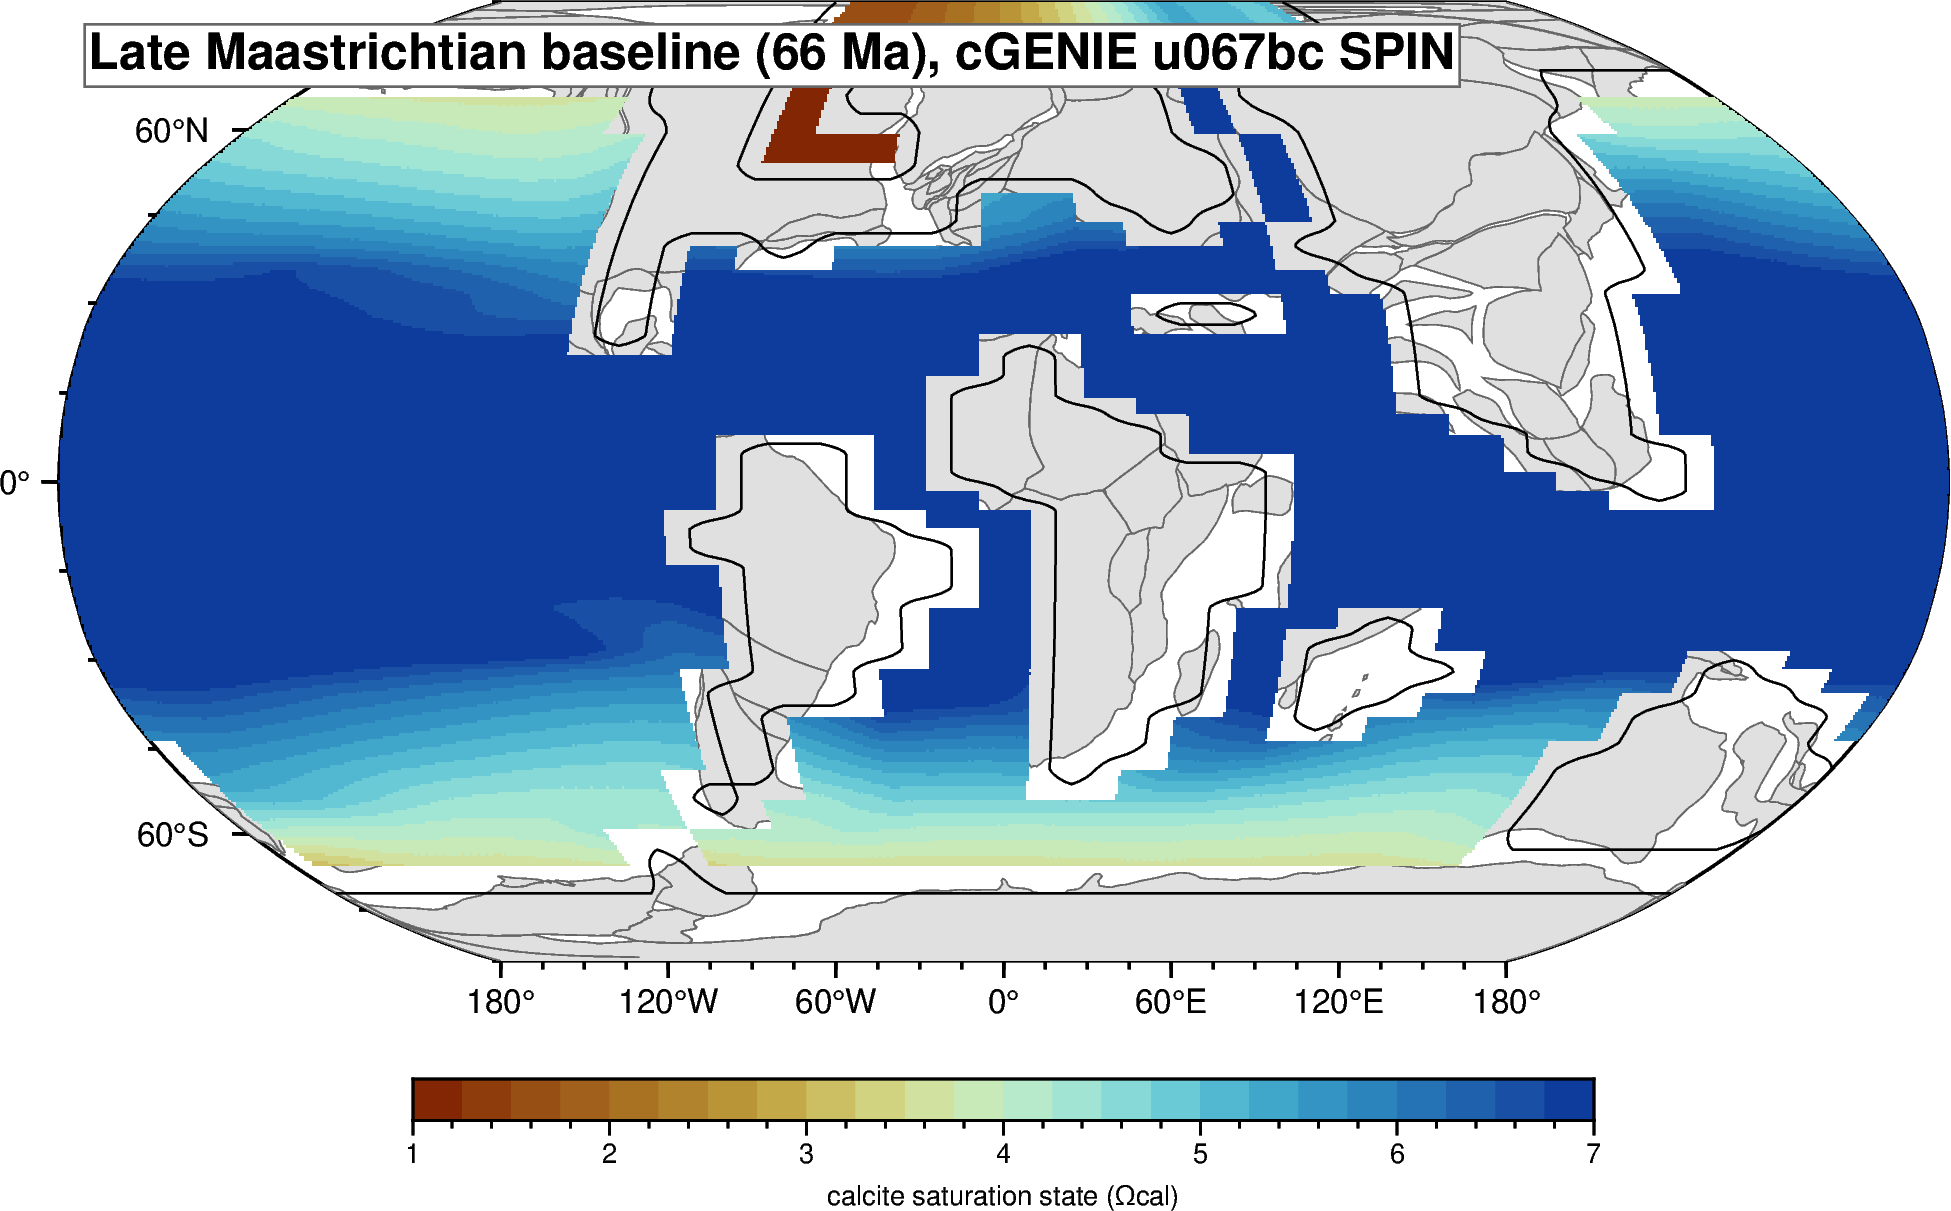

In [4]:
pmm = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="data/pmm_cache")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)
gm = gplately.PlotTopologies(
    plate_reconstruction=recon,
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=float(RECON_AGE_MA),
    plot_engine=gplately.PygmtPlotEngine(),
)

BASELINE_FIELDS = [
    ("ocn_sur_temp", "roma", [10, 32, 1], "sea-surface temperature (\u00b0C)"),
    ("misc_pH", "roma", [7.4, 8.0, 0.02], "surface pH"),
    ("carb_sur_ohm_cal", "roma", [1, 7, 0.25], "calcite saturation state (\u03a9cal)"),
]

baseline = snapshots.sel(exp="SPIN_baseline")
# Build a smooth, contourable 0/1 version of the land-sea mask (ocean=1, land=0)
# for grdcontour. grdcontour needs an actual numeric crossing of its contour
# level to trace a line; refining the raw NaN-for-land mask directly leaves
# NaN cliffs with no 0-1 gradient to contour, so grdcontour silently finds
# nothing to draw. Converting NaN->0 *before* refine_for_plot's bilinear
# resample creates that gradient.
mask_plot = refine_for_plot(xr.where(np.isnan(baseline["grid_mask"]), 0.0, 1.0))

for var, cmap, series, label in BASELINE_FIELDS:
    field = baseline[var].where(baseline["grid_mask"] > 0)
    field_plot = refine_for_plot(field)

    fig = pygmt.Figure()
    pygmt.makecpt(cmap=cmap, series=series, background="o")
    fig.basemap(region=REGION, projection=PROJ, frame="af")
    gm.plot_continents(fig, fill="gray88", pen="0.3p,gray40")
    fig.grdimage(grid=field_plot, nan_transparent=True)
    fig.grdcontour(grid=mask_plot, levels=[0.5], pen="0.5p,black")
    fig.colorbar(frame=f"af+l{label}", position="JBC+w10c/0.35c+h+o0/1c")
    fig.text(text=f"Late Maastrichtian baseline ({RECON_AGE_MA:.0f} Ma), cGENIE u067bc SPIN",
              position="TL", offset="0.25c/-0.25c", justify="TL",
              font="12p,Helvetica-Bold,black", fill="white", pen="0.5p,gray40")
    fig.savefig(OUTPUT_DIR / f"T69_baseline_{var}.png", dpi=150)
    fig.show(width=700)


**What this shows.** Pre-impact, the model runs a warm greenhouse ocean: global-mean SST is 26.4°C (matching Ying et al. 2026's reported late-Maastrichtian spin-up value), with the tropics well above 30°C and only the highest latitudes dropping below 10°C — there is no permanent polar ice in this world. Surface pH sits in a tight 7.6-8.0 band, and calcite saturation state is supersaturated (Ω_cal > 1) across almost the entire low- and mid-latitude ocean, dropping toward or below saturation only at the poles — the normal, healthy carbonate chemistry that late-Cretaceous calcifiers (including the ammonites and planktic foraminifera discussed in T70/T71) evolved under. Every anomaly in §4 is measured against this baseline.

## 3. GPlately-reconstructed 66 Ma paleogeography, for comparison

cGENIE's own K-Pg boundary conditions (the continental outline visible in the maps above) come from the model group's own paleogeographic reconstruction — a configuration that matches the Scotese & Wright (2018) plate model, even though cGENIE's own documentation does not name a source model explicitly. This section reconstructs modern coastlines to 66 Ma with `gplately` using that same model, so the panel below is a **consistency check**: does an independent `gplately` reconstruction of Scotese & Wright (2018) line up with the continental outline cGENIE actually used as its boundary condition? (Contrast this with T70/T71, which reuse this same reconstruction purely as a map-context overlay.)

grdcontour [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


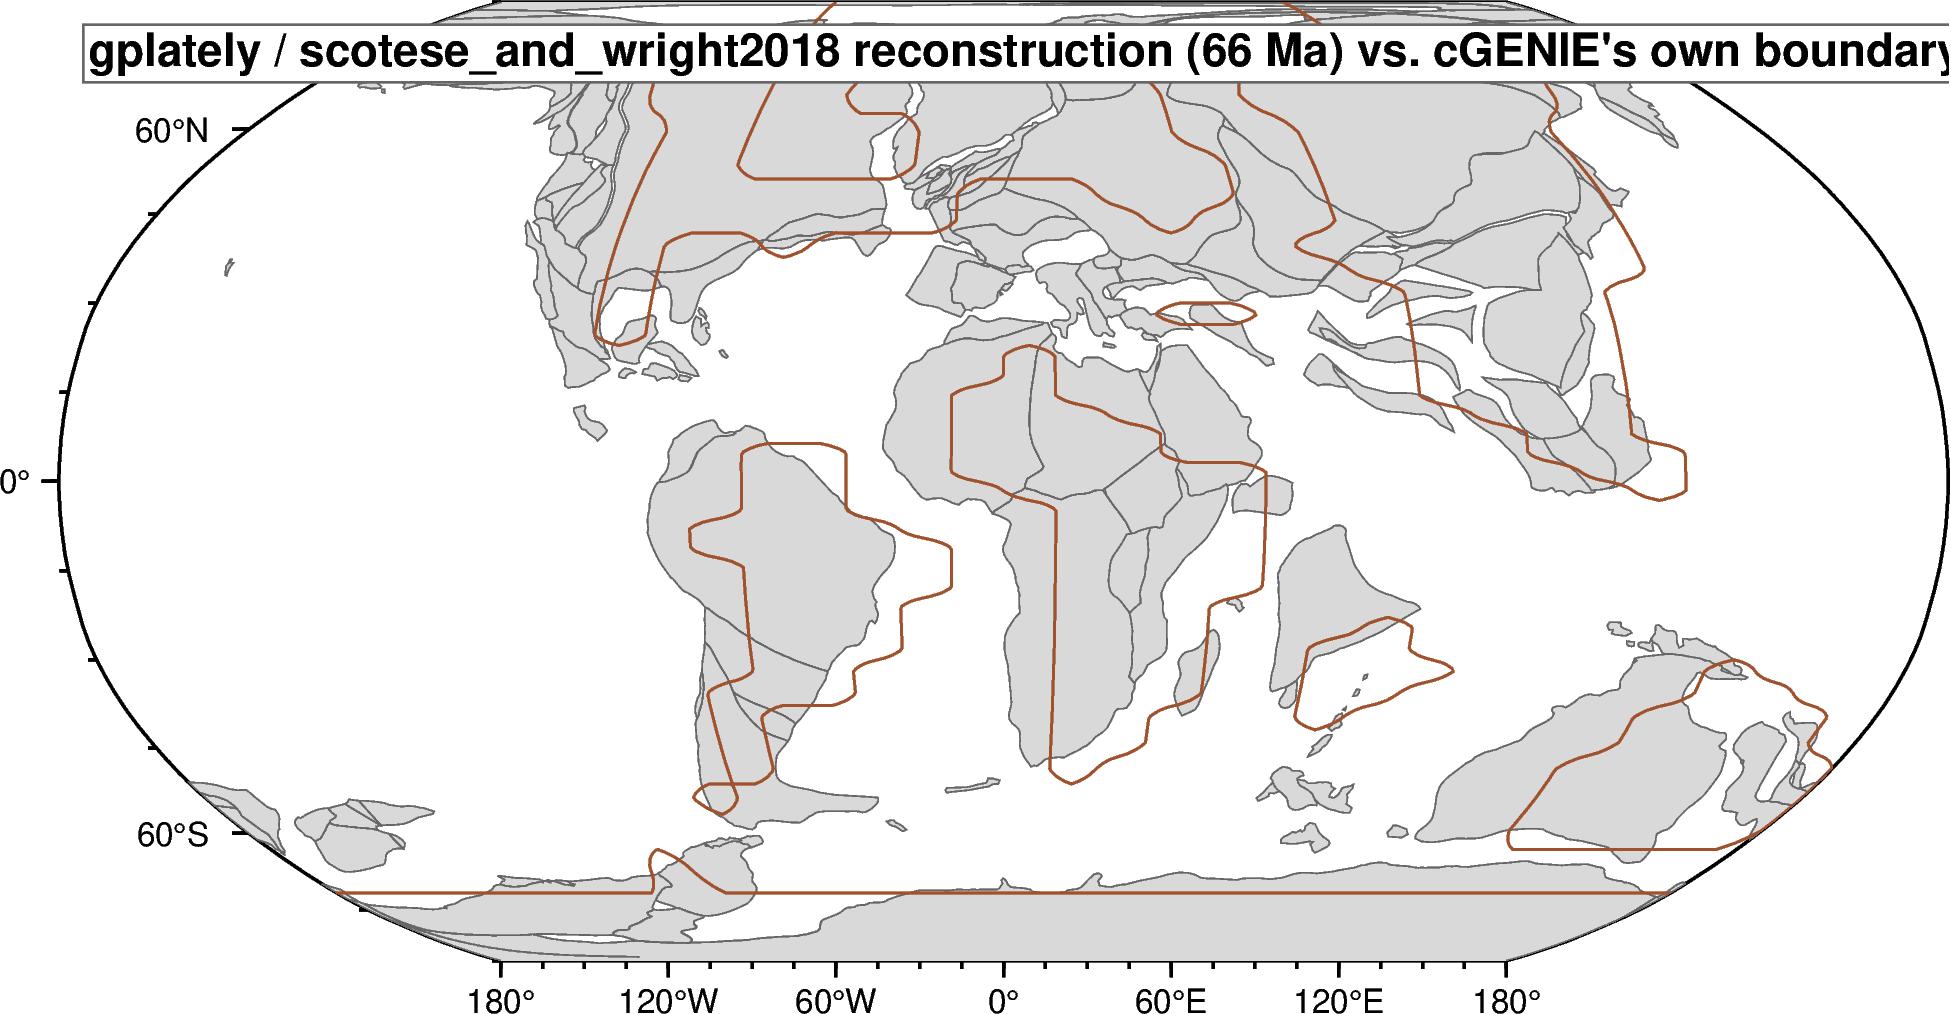

In [5]:
fig = pygmt.Figure()
fig.basemap(region=REGION, projection=PROJ, frame="af")
gm.plot_continents(fig, fill="gray85", pen="0.3p,gray40")
fig.grdcontour(grid=mask_plot, levels=[0.5], pen="0.6p,sienna")
fig.text(text=f"gplately / {MODEL_NAME} reconstruction ({RECON_AGE_MA:.0f} Ma) vs. cGENIE's own boundary (sienna line)",
          position="TL", offset="0.25c/-0.25c", justify="TL",
          font="11p,Helvetica-Bold,black", fill="white", pen="0.5p,gray40")
fig.savefig(OUTPUT_DIR / "T69_gplately_66Ma_coastlines.png", dpi=150)
fig.show(width=700)


**What this shows.** The gray `gplately`/Scotese & Wright (2018) continent fill and the sienna contour line (cGENIE's own land-sea mask boundary) track each other closely across every continent — both show the same Late Cretaceous Atlantic already open, India mid-transit across the Indian Ocean, and a still-narrow proto-North Atlantic. Small mismatches in coastline detail (e.g. shelf-margin position, small-basin geometry) are expected: cGENIE discretises the reconstructed geography onto its own coarse 36x36 ocean grid, so its boundary is a *rasterised* version of the same underlying paleogeography, not a pixel-identical copy. That agreement is the point of this panel — it confirms the overlay used on every other map in this notebook is drawn from the same paleogeographic source cGENIE itself ran on, rather than a mismatched independent reconstruction.

## 4. The crisis — before/after anomaly maps

Anomalies (crisis minus baseline) at two points in the 100-year `main` experiment: peak impact-winter cooling (year 103.5, a few years in — the darkness/dust pulse is brief but the ocean's thermal response lags it slightly) and 100 years later (year 199.5, the end of the run). The early snapshot is dominated by the solar-dimming/impact-winter signal (severe transient cooling and a sharp pH drop); the year-199.5 snapshot shows the system has already flipped sign on temperature — CO2-driven warming has overtaken the darkness pulse — while the pH depression has settled into a smaller, persistent offset from baseline.

grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


grdcontour [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


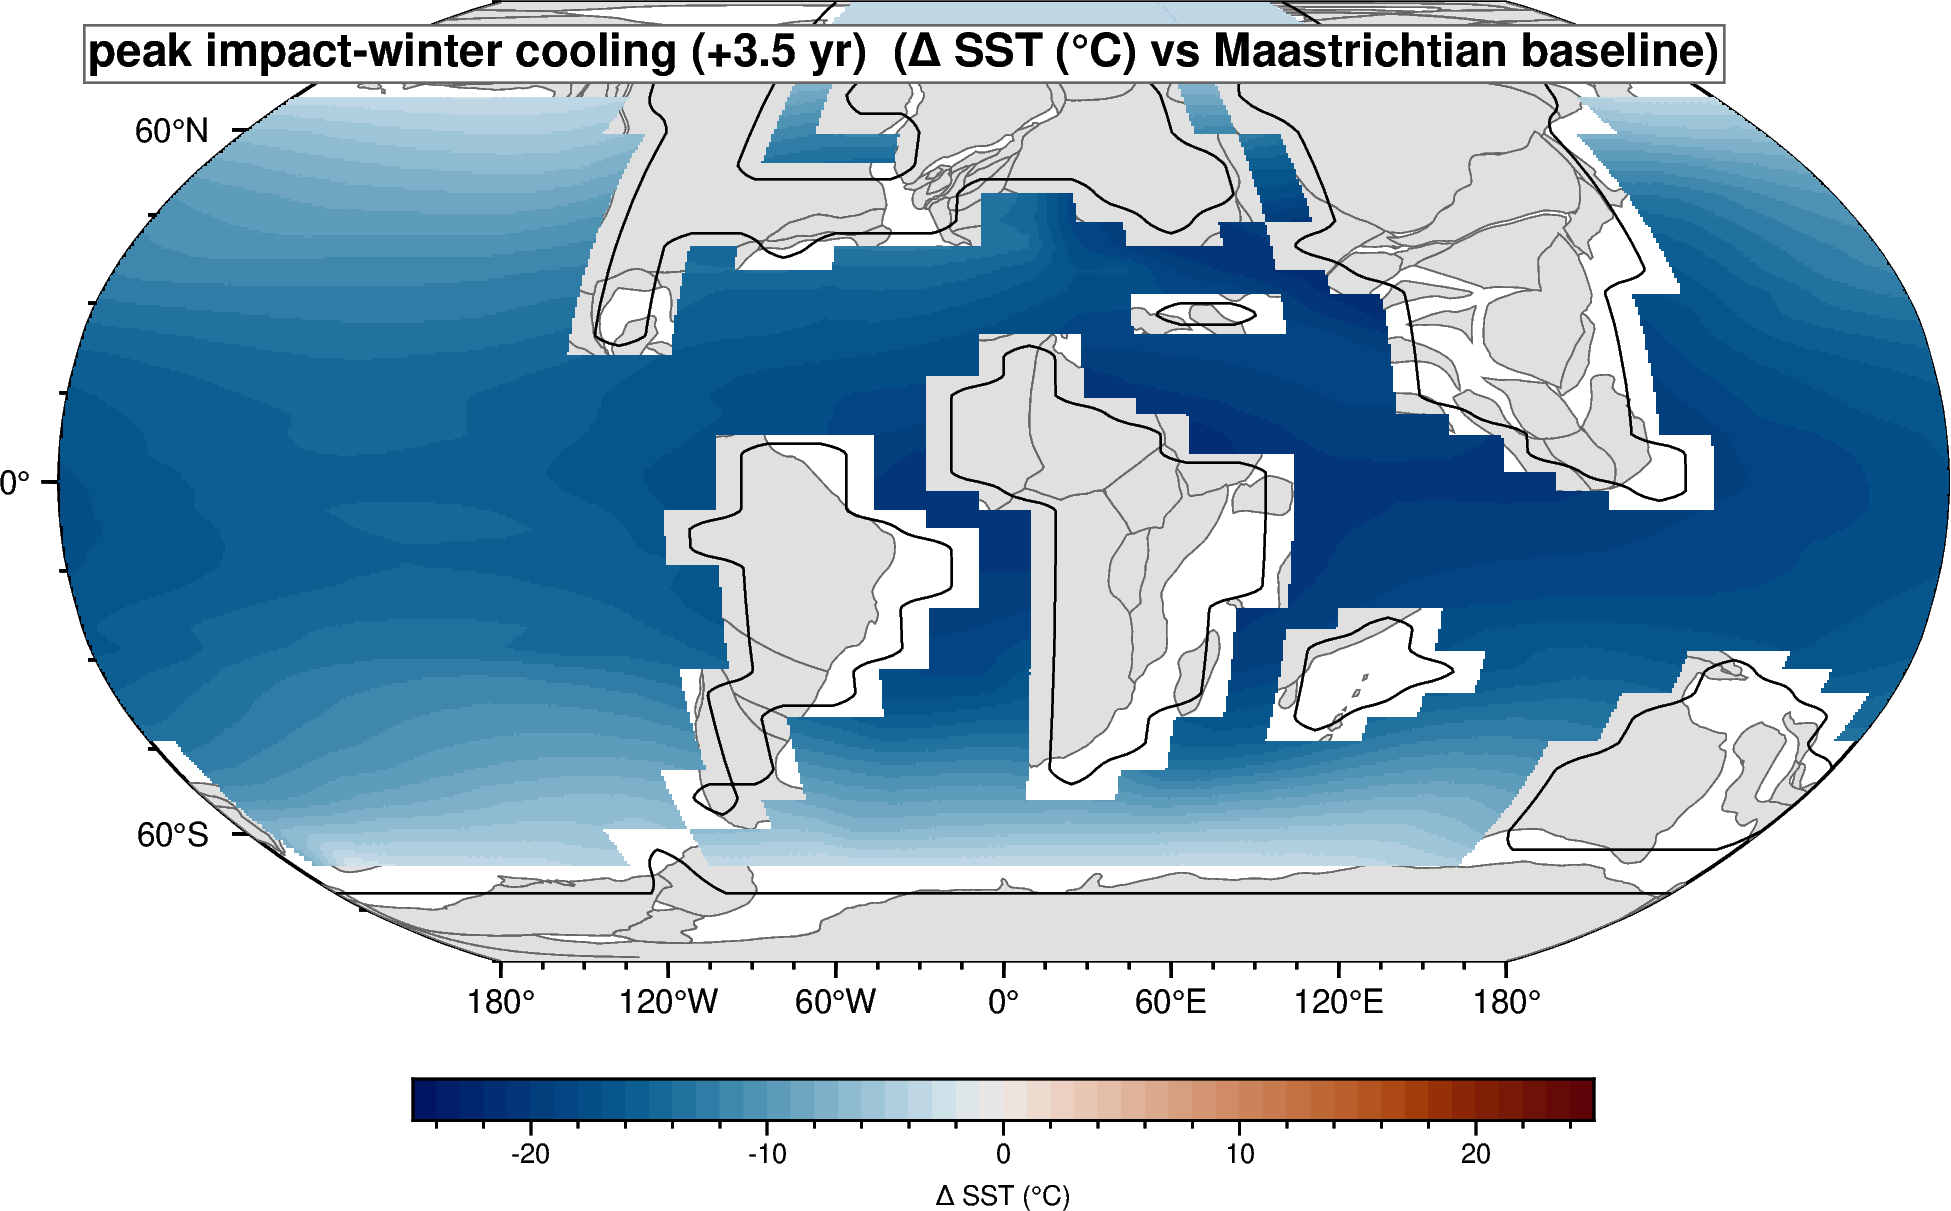

grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


grdcontour [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


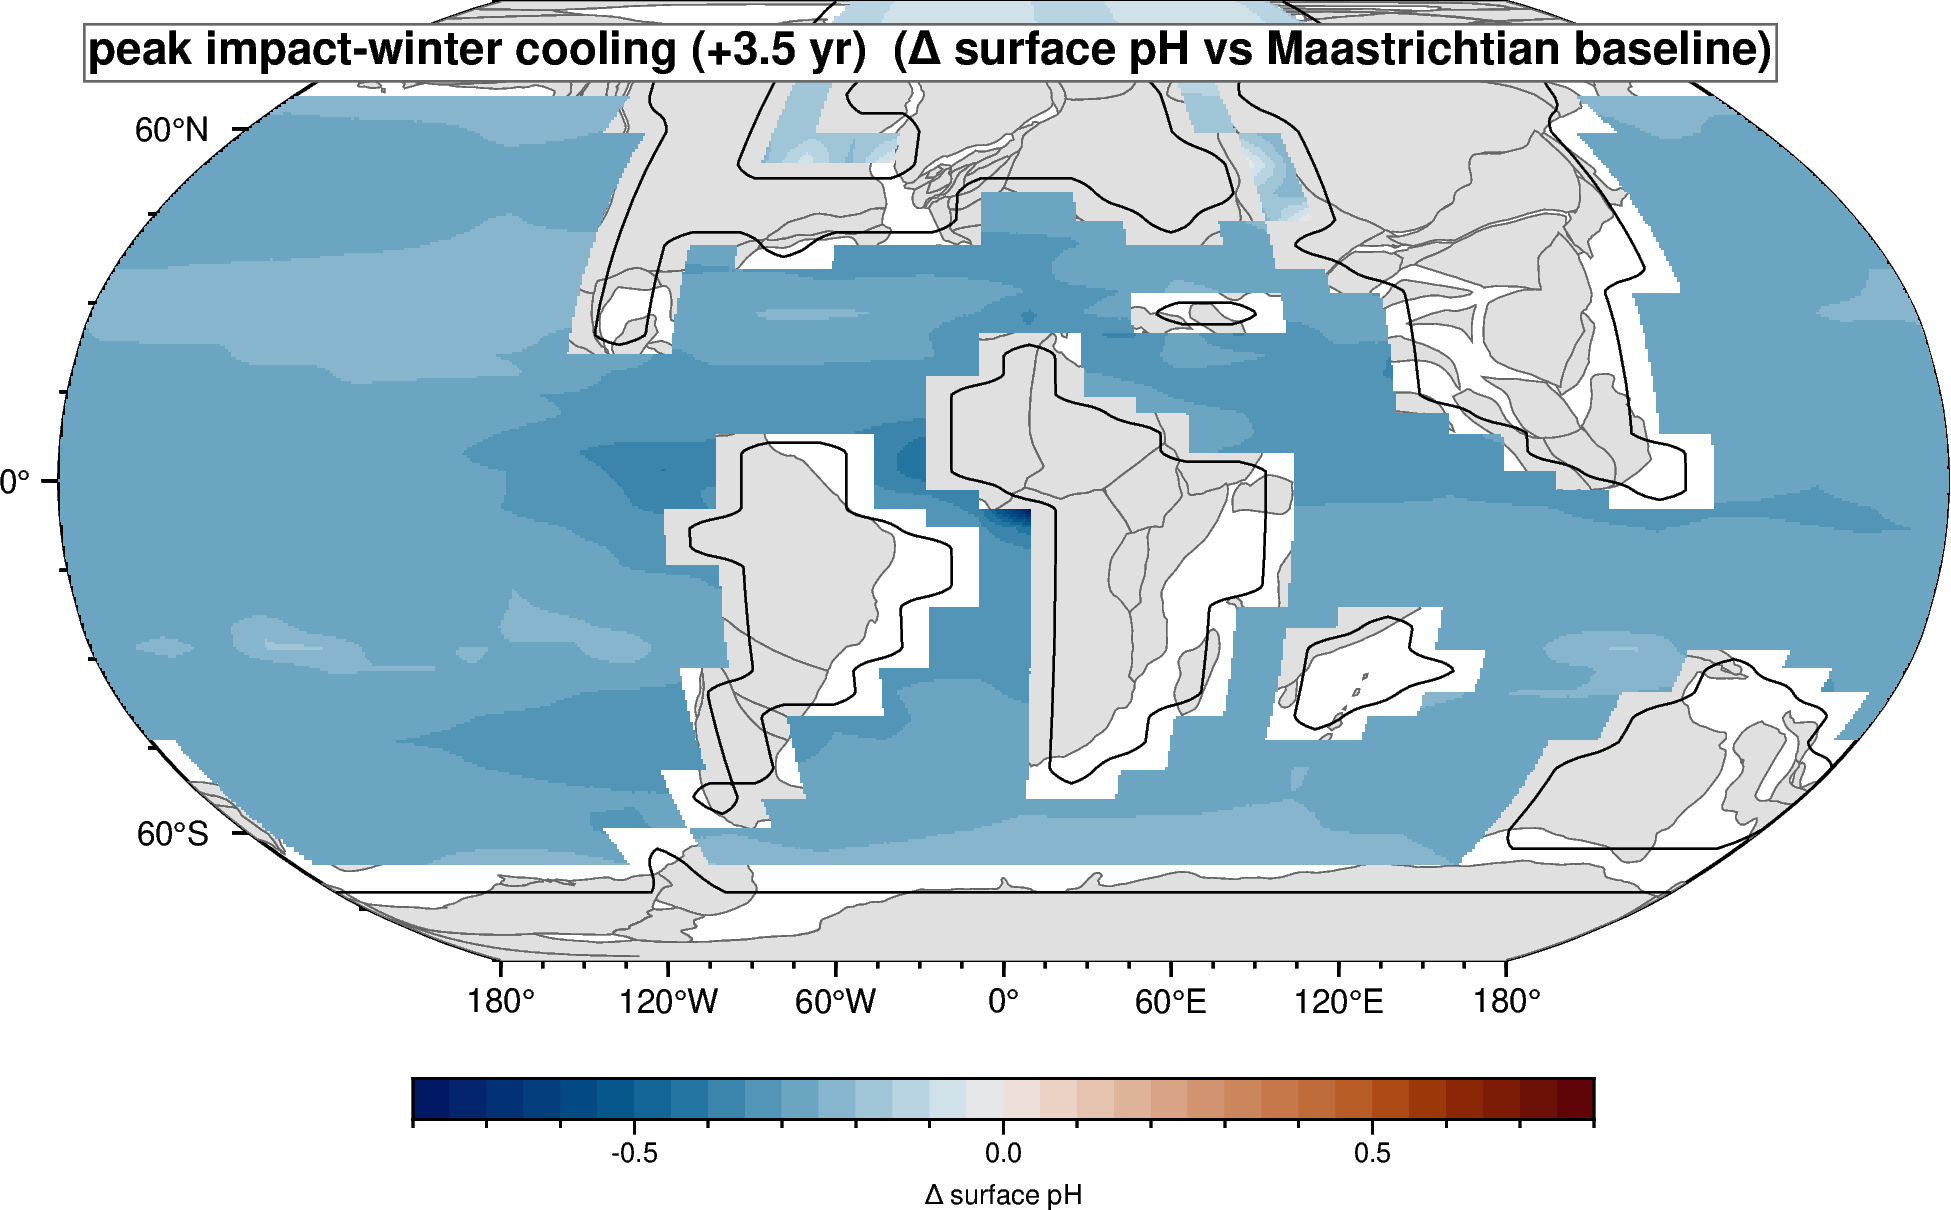

grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


grdcontour [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


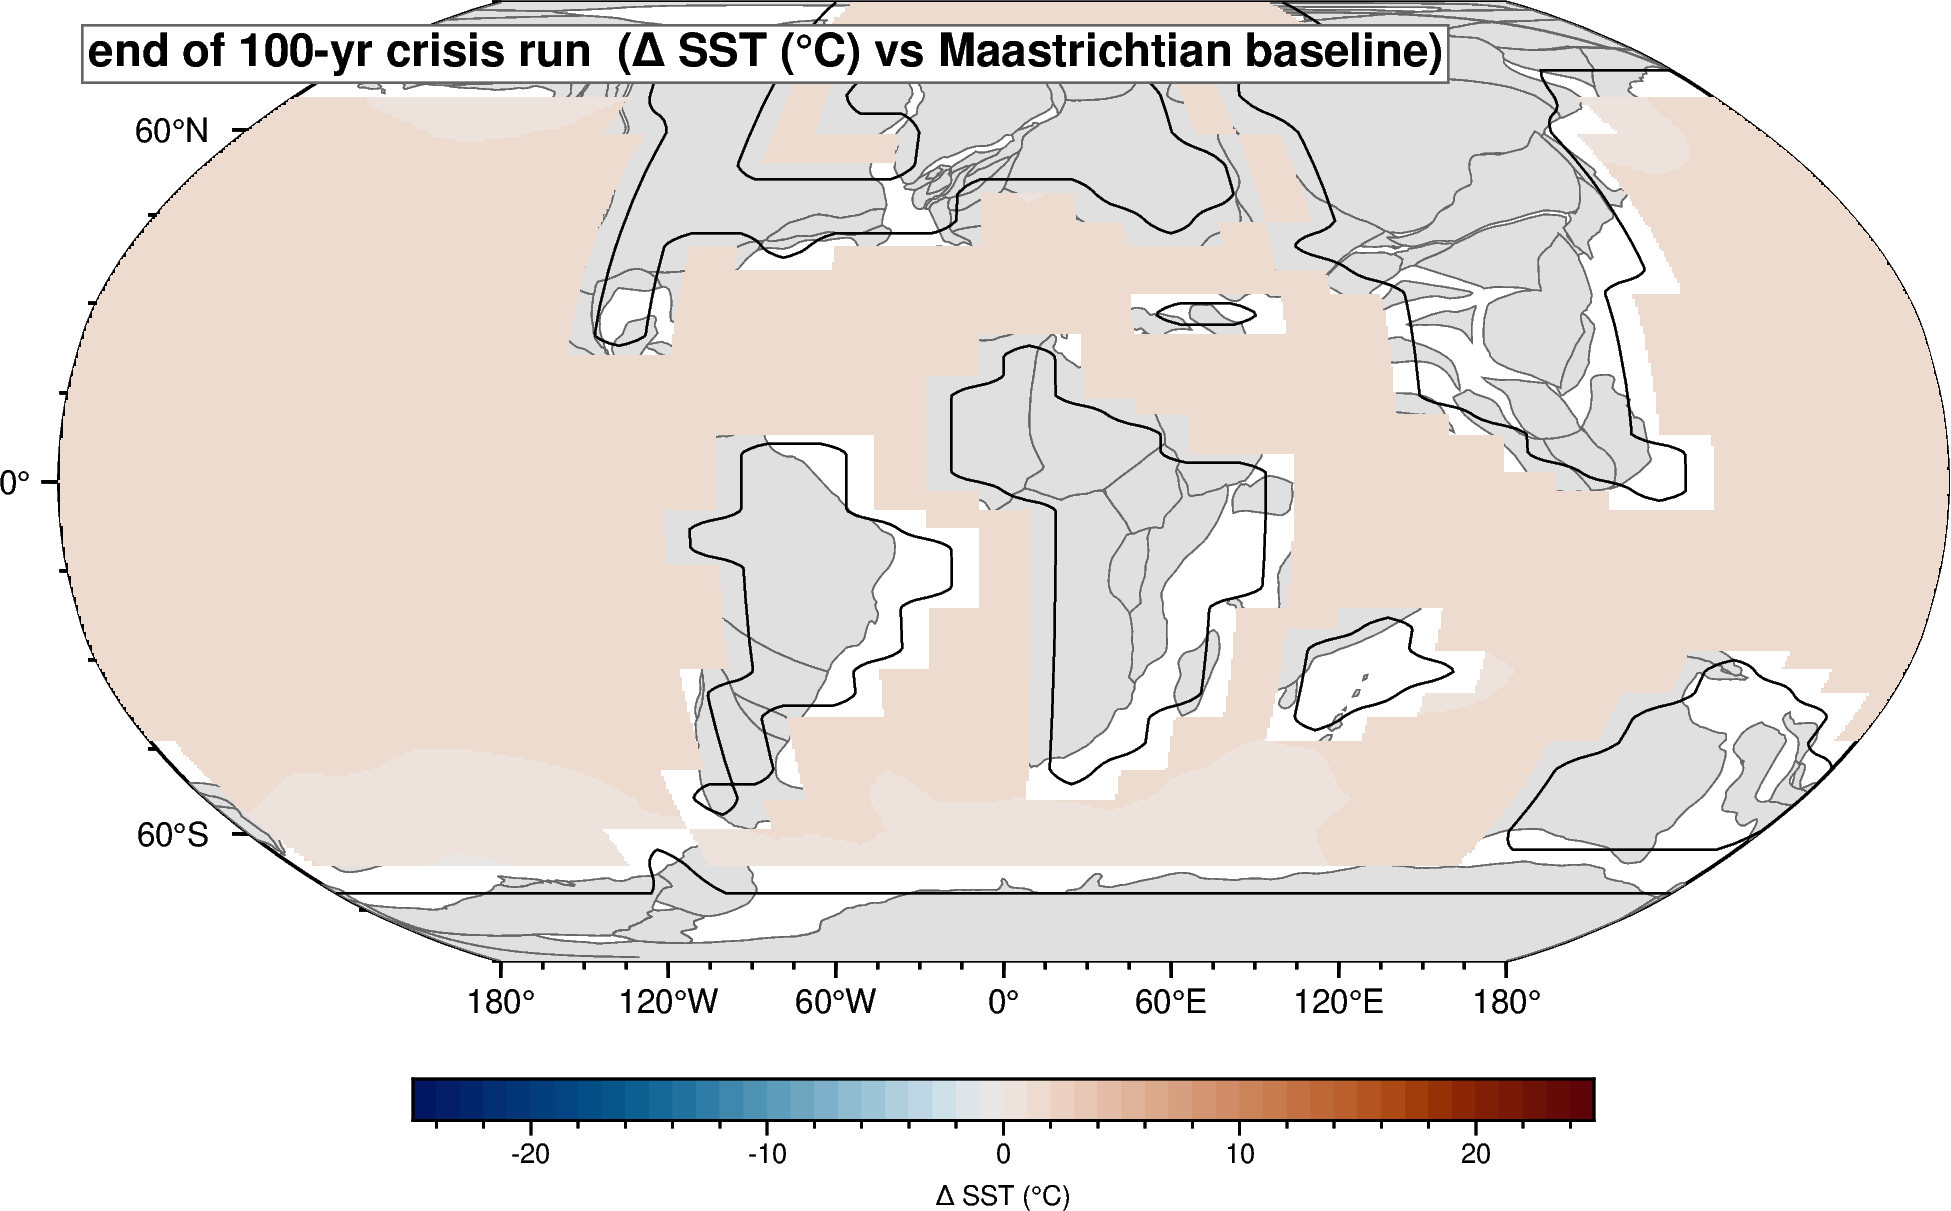

grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


grdcontour [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


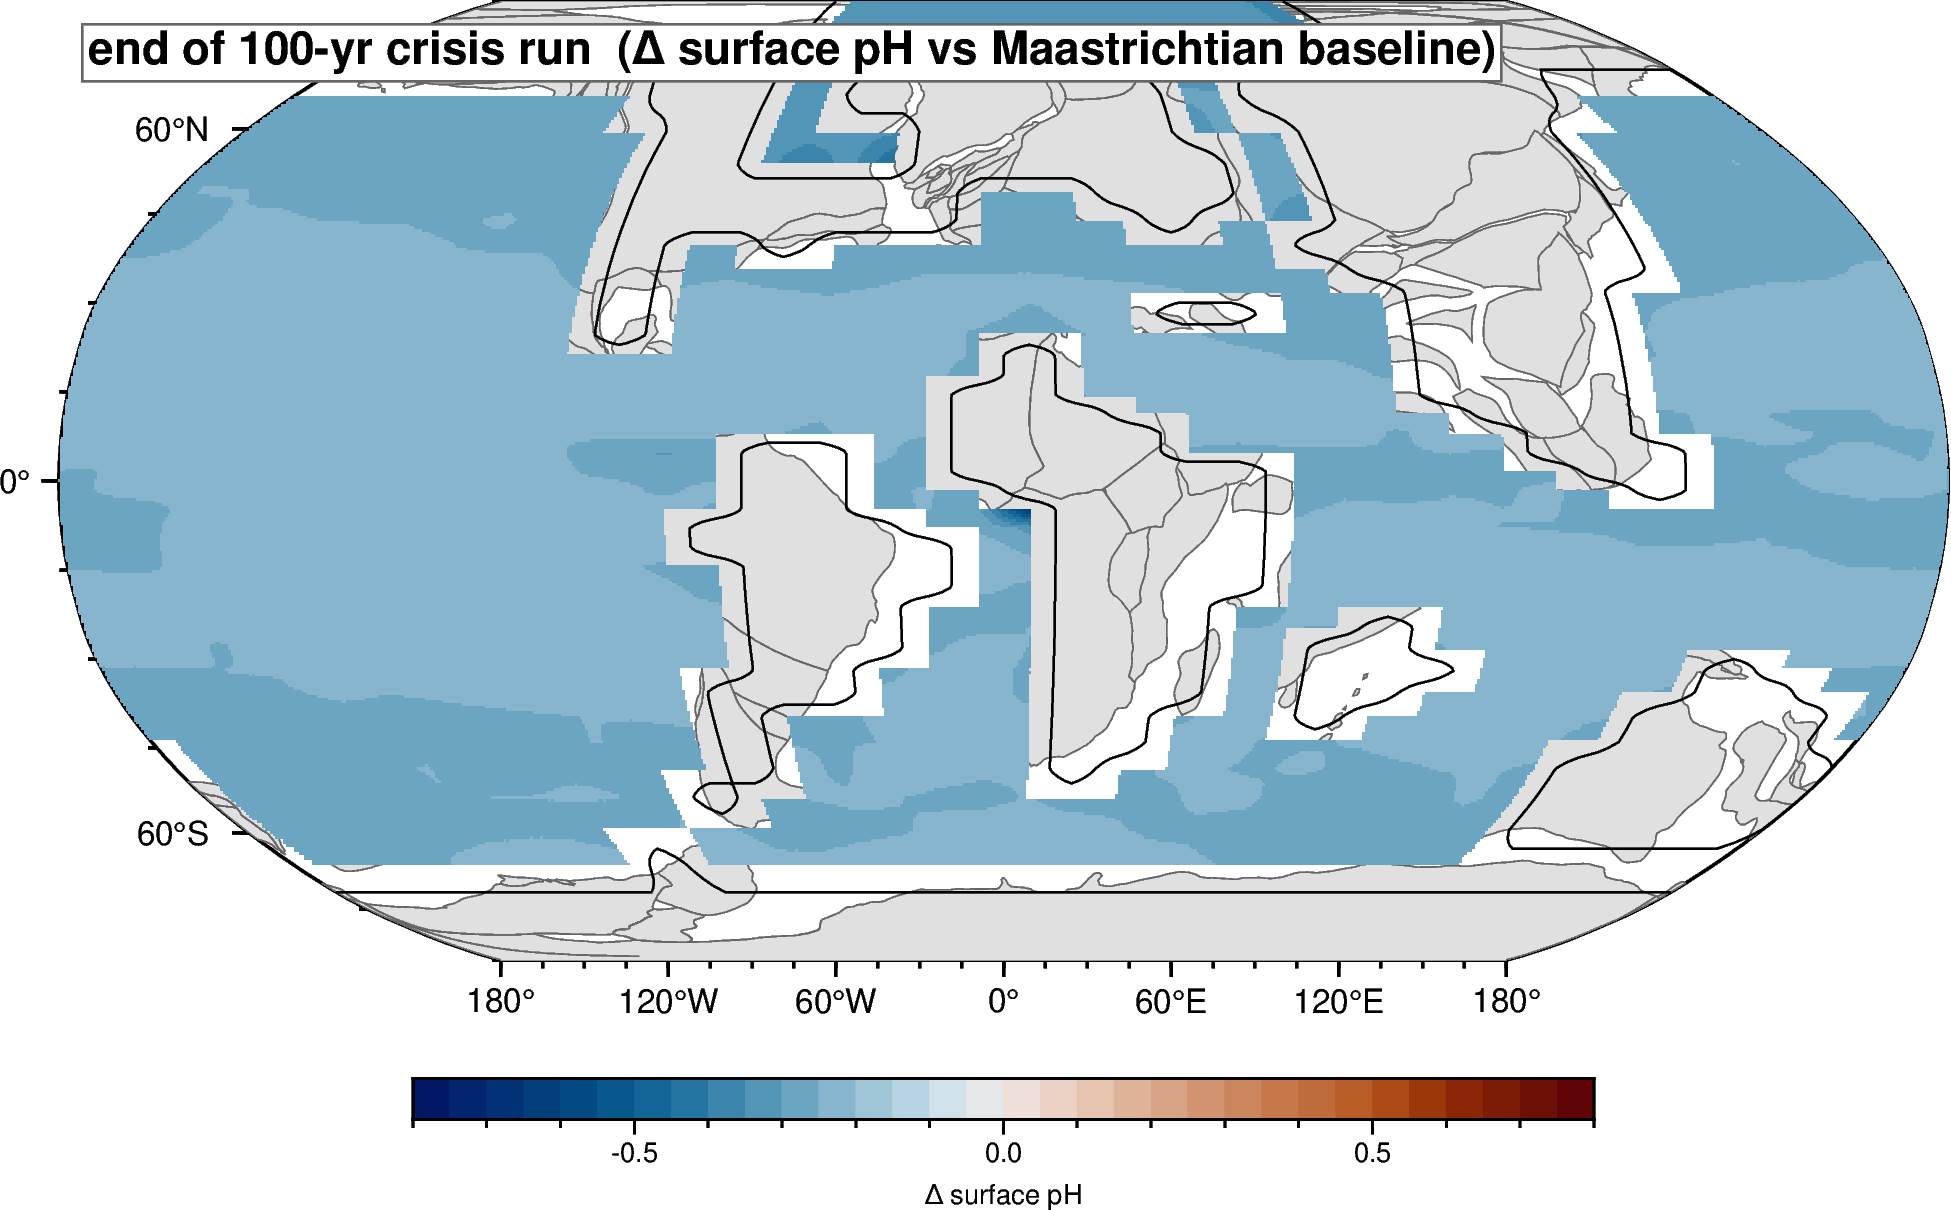

In [6]:
ANOMALY_SNAPSHOTS = [("main_t103.5", "peak impact-winter cooling (+3.5 yr)"),
                      ("main_t199.5", "end of 100-yr crisis run")]
ANOMALY_FIELDS = [("ocn_sur_temp", "vik", [-25, 25, 1], "\u0394 SST (\u00b0C)"),
                   ("misc_pH", "vik", [-0.8, 0.8, 0.05], "\u0394 surface pH")]

base_vals = {var: baseline[var].where(baseline["grid_mask"] > 0) for var, *_ in ANOMALY_FIELDS}

for exp_key, exp_label in ANOMALY_SNAPSHOTS:
    snap = snapshots.sel(exp=exp_key)
    for var, cmap, series, label in ANOMALY_FIELDS:
        field = snap[var].where(snap["grid_mask"] > 0)
        anomaly = field - base_vals[var]
        anomaly_plot = refine_for_plot(anomaly)

        fig = pygmt.Figure()
        pygmt.makecpt(cmap=cmap, series=series, background="o")
        fig.basemap(region=REGION, projection=PROJ, frame="af")
        gm.plot_continents(fig, fill="gray88", pen="0.3p,gray40")
        fig.grdimage(grid=anomaly_plot, nan_transparent=True)
        fig.grdcontour(grid=mask_plot, levels=[0.5], pen="0.5p,black")
        fig.colorbar(frame=f"af+l{label}", position="JBC+w10c/0.35c+h+o0/1c")
        fig.text(text=f"{exp_label}  ({label} vs Maastrichtian baseline)",
                  position="TL", offset="0.25c/-0.25c", justify="TL",
                  font="11p,Helvetica-Bold,black", fill="white", pen="0.5p,gray40")
        fig.savefig(OUTPUT_DIR / f"T69_anomaly_{exp_key}_{var}.png", dpi=150)
        fig.show(width=700)


**What this shows.** At peak impact-winter cooling (+3.5 yr) the global-mean SST anomaly is about -14°C (global mean drops from 26.4°C to roughly 12°C, matching Ying et al. 2026's reported minimum of 12.3°C three years post-impact) with the strongest cooling in mid-to-high latitudes and a simultaneous pH drop of up to -0.8 units in the worst-affected regions. By the end of the 100-yr run the SST anomaly has flipped to *positive* (CO2-driven greenhouse warming has overtaken the transient darkness pulse), while surface pH remains depressed by roughly -0.2 to -0.3 units almost everywhere — the acidification signal, unlike the temperature swing, does not reverse within the crisis window. This two-phase pattern (fast, severe darkness-driven cooling, followed by slower CO2-driven warming with a longer-lived acidification offset) is exactly what §6's forcing decomposition unpacks mechanistically.

## 5. Global-mean time series through crisis + recovery

The `main` experiment's 100-yr crisis and the `Danian` experiment's 5,000-yr recovery are two separate model runs (the latter restarted from the former's endpoint); stitched together here on a common "years since impact" axis, using each experiment's own global-mean `.res` output.

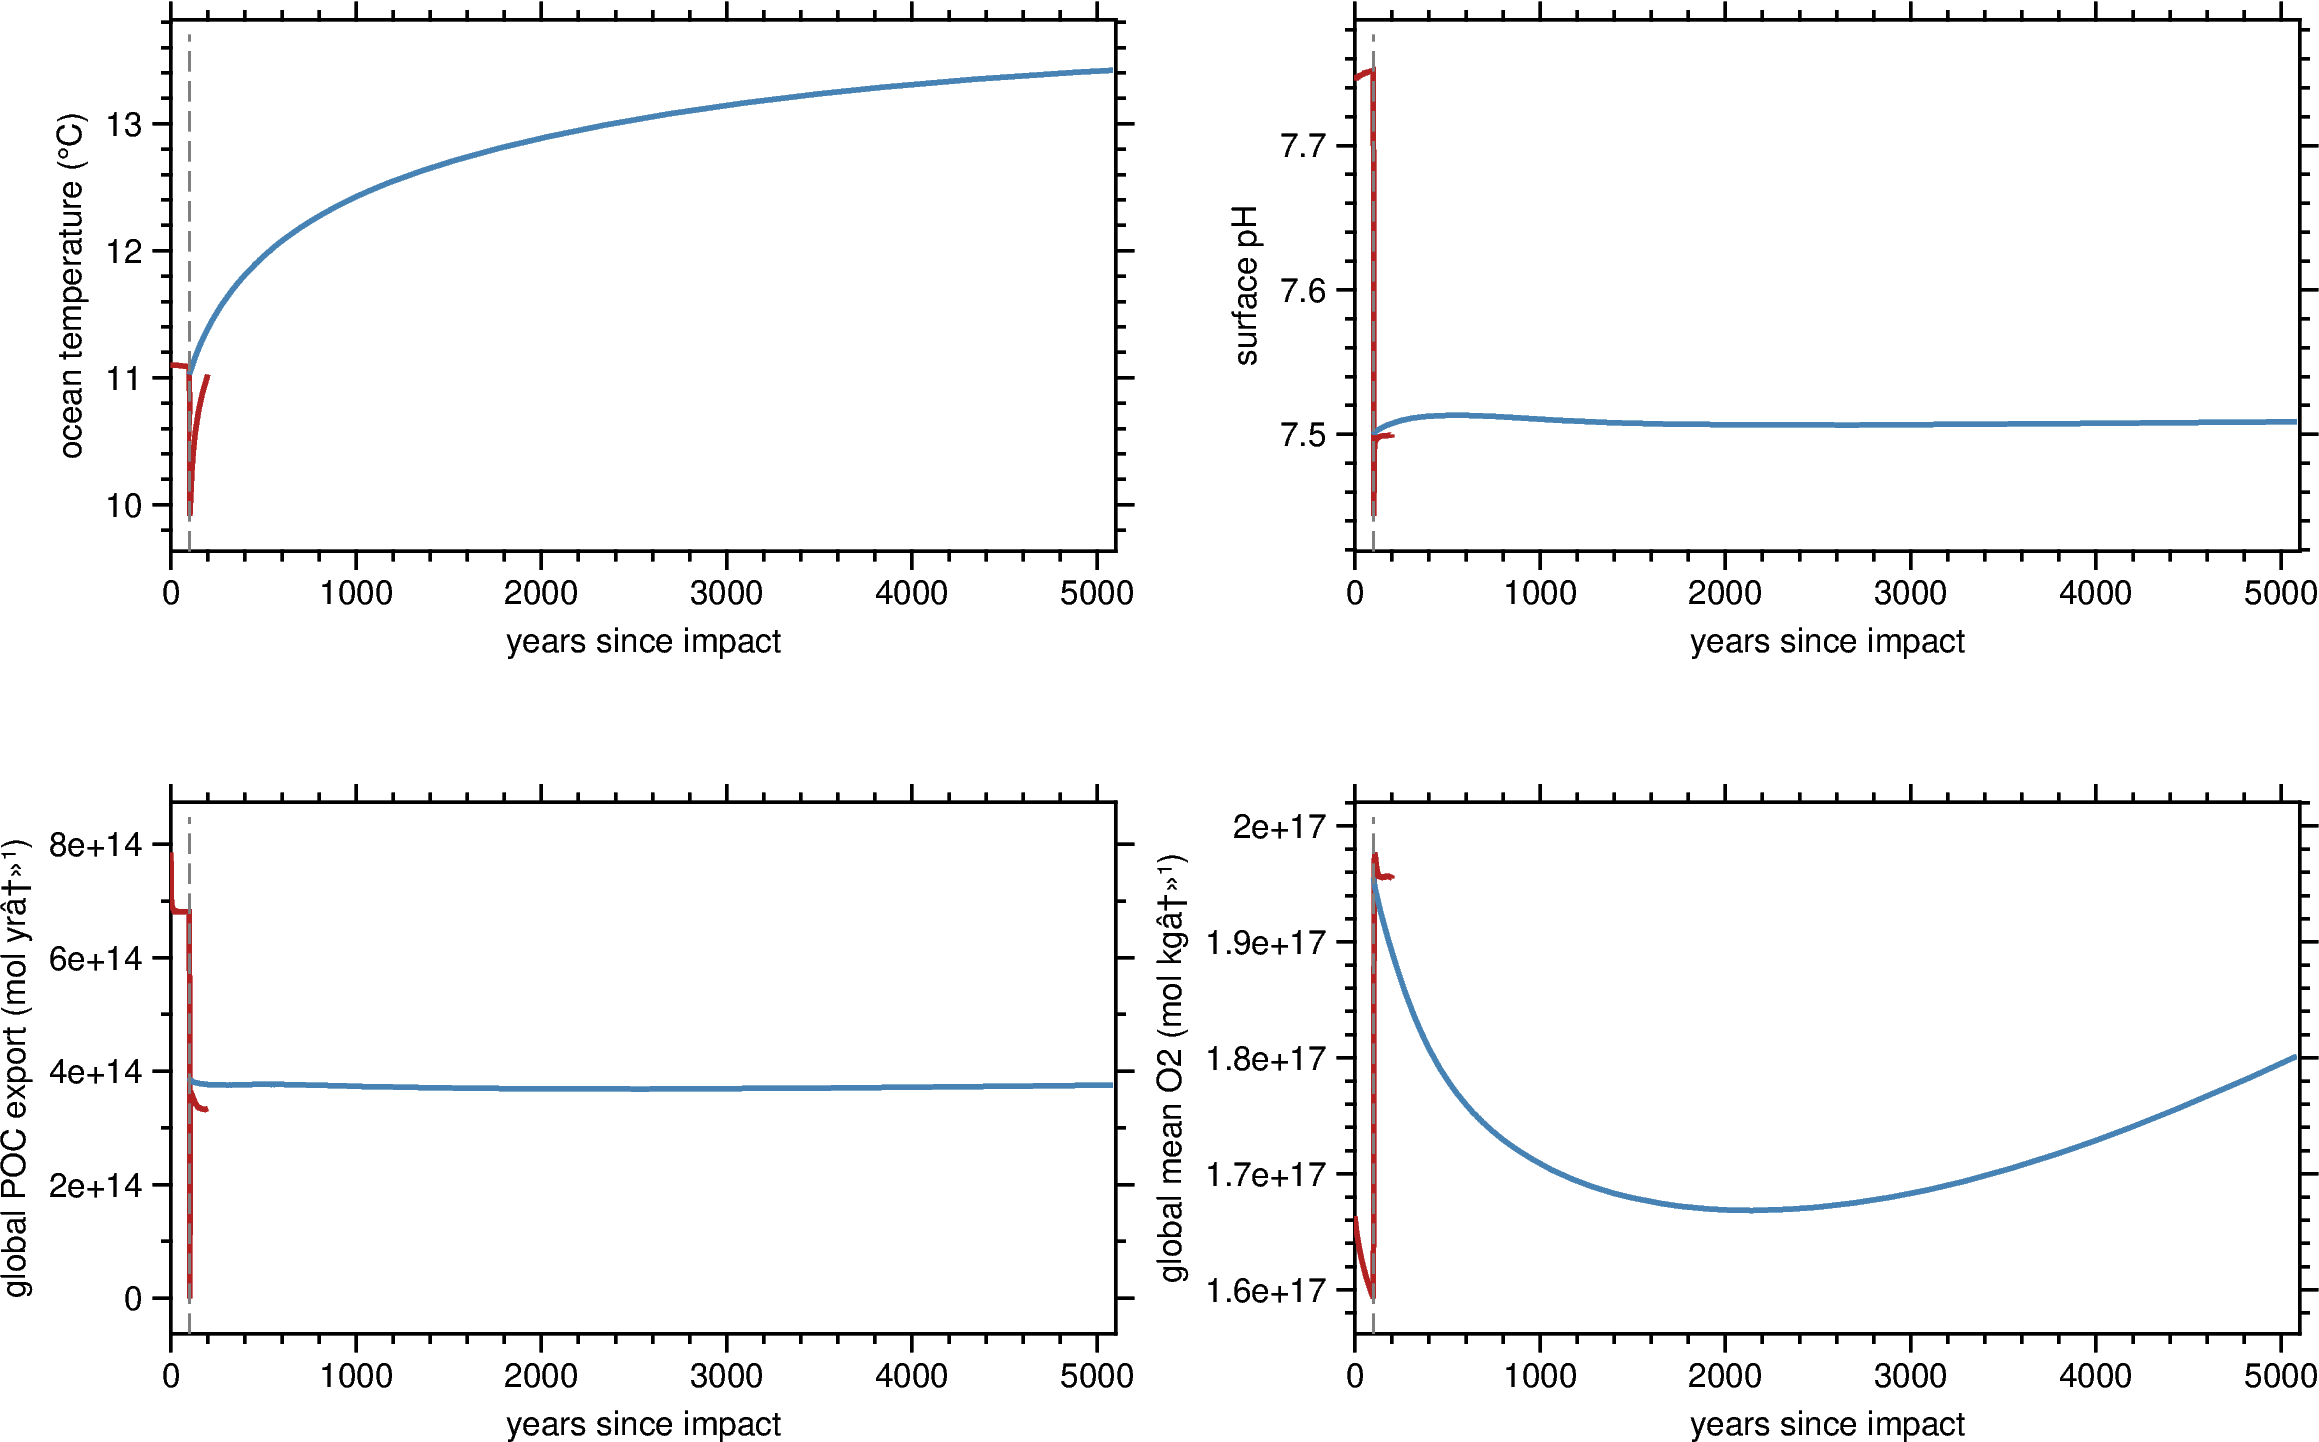

  red = main (100-yr crisis)   blue = Danian (5,000-yr recovery)   dashed line = impact + 100 yr handoff


In [7]:
SERIES_PANELS = [("ocn_temp", "ocean temperature (\u00b0C)"),
                  ("surpH", "surface pH"),
                  ("fexport_POC", "global POC export (mol yr\u207b\u00b9)"),
                  ("ocn_O2", "global mean O2 (mol kg\u207b\u00b9)")]

main_ts = timeseries[timeseries["experiment"] == "main"].copy()
danian_ts = timeseries[timeseries["experiment"] == "Danian"].copy()
danian_ts["time_yr"] = danian_ts["time_yr"] + 100.0  # Danian restarts at main's endpoint

fig = pygmt.Figure()
with fig.subplot(nrows=2, ncols=2, figsize=("18c", "11c"), margins=["0.8c", "0.9c"]):
    for i, (var, label) in enumerate(SERIES_PANELS):
        m = main_ts[main_ts["variable"] == var].sort_values("time_yr")
        d = danian_ts[danian_ts["variable"] == var].sort_values("time_yr")
        combined = pd.concat([m, d])
        y_min, y_max = combined["value"].min(), combined["value"].max()
        pad = (y_max - y_min) * 0.08 or 1
        with fig.set_panel(panel=i):
            fig.basemap(region=[0, 5100, y_min - pad, y_max + pad],
                        projection="X8c/4.5c",
                        frame=["WSne", "xaf+lyears since impact", f"yaf+l{label}"])
            fig.plot(x=m["time_yr"], y=m["value"], pen="1.2p,firebrick")
            fig.plot(x=d["time_yr"], y=d["value"], pen="1.2p,steelblue")
            fig.plot(x=[100, 100], y=[y_min - pad, y_max + pad], pen="0.6p,gray50,-")
fig.savefig(OUTPUT_DIR / "T69_global_timeseries.png", dpi=150)
fig.show(width=900)
print("  red = main (100-yr crisis)   blue = Danian (5,000-yr recovery)   dashed line = impact + 100 yr handoff")


**What this shows.** All four global-mean tracers plunge within the first few years of `main` (the red segment) and then only partially recover before the 100-yr handoff to `Danian` (blue): ocean temperature and POC export production both settle into a multi-thousand-year climb back toward — but, within this 5 kyr window, not fully back to — their pre-impact levels, consistent with Ying et al. 2026's reported ~30-year *ecological* recovery timescale for the plankton community sitting inside a much longer (multi-millennial) *physical/chemical* ocean recovery. Global mean O2 shows the clearest overshoot-and-recover trajectory: it dips for roughly 2,000 years (reduced export production means less remineralisation-driven demand initially, then a slow rebuild) before climbing back through the end of the record. Surface pH is the fastest variable to stabilise, settling within a few hundred years of the impact — the CO2 perturbation itself is comparatively short-lived even though the ocean's biological and thermal state takes far longer to re-equilibrate.

## 6. Forcing decomposition — which mechanism drove the change?

The `main` experiment combines solar dimming, CO2 release, and dust/iron deposition simultaneously. Three sensitivity experiments isolate parts of that: `solar` (dimming only, no CO2 increase), `CO2` (CO2 forcing only, no dimming), and `noextinction` (full combined forcing, but the plankton extinction mechanism itself disabled — a control for how much of the biogeochemical anomaly is driven by the physical forcing alone versus feedback from the ecosystem collapse). Comparing each sensitivity run's peak-crisis anomaly (year 103.5) against `main`'s isolates each mechanism's individual contribution.

variable                         Δ SST (°C)  Δ surface pH
experiment                                               
CO2 forcing only                      0.609        -0.270
combined (main)                     -14.162        -0.276
combined, no ecosystem feedback     -14.162        -0.236
solar dimming only                  -14.327        -0.078


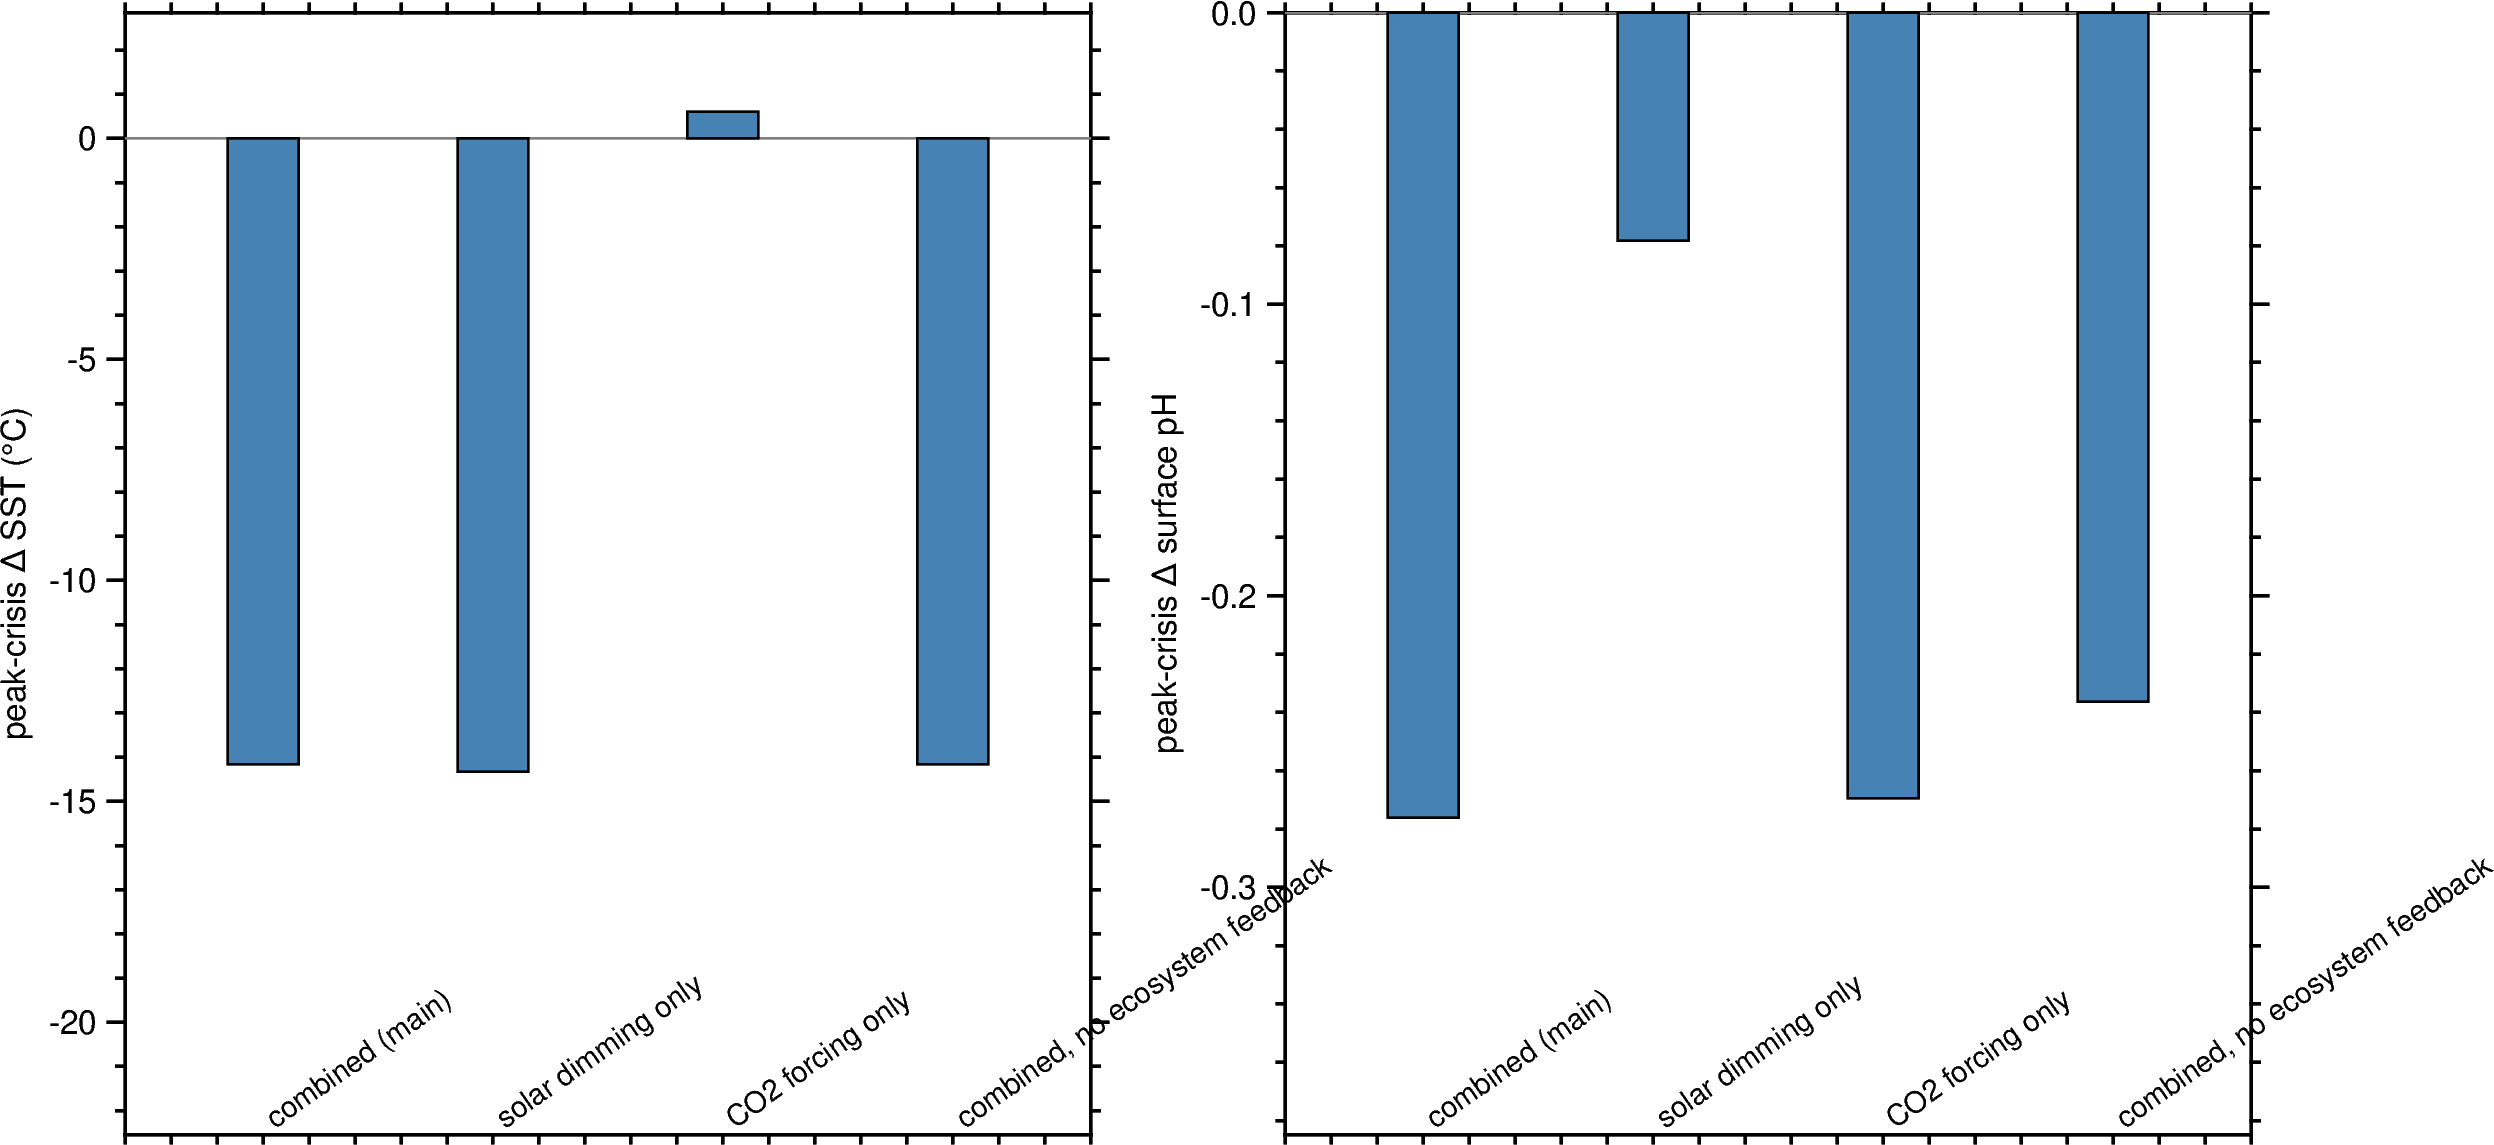

In [8]:
DECOMP_EXPS = [("main_t103.5", "combined (main)"),
               ("solar_only_peak", "solar dimming only"),
               ("CO2_only_peak", "CO2 forcing only"),
               ("noextinction_peak", "combined, no ecosystem feedback")]

rows = []
for exp_key, exp_label in DECOMP_EXPS:
    snap = snapshots.sel(exp=exp_key)
    for var, _, _, label in ANOMALY_FIELDS:
        field = snap[var].where(snap["grid_mask"] > 0)
        anom = float((field - base_vals[var]).mean(skipna=True))
        rows.append({"experiment": exp_label, "variable": label, "mean_anomaly": anom})
decomp = pd.DataFrame(rows)
print(decomp.pivot(index="experiment", columns="variable", values="mean_anomaly").round(3))

fig = pygmt.Figure()
# NOTE: use an auto-sized panel projection ("X?") rather than a fixed cm size here.
# fig.subplot() pre-computes each panel's true drawable box from figsize/margins;
# a hardcoded projection (e.g. "X8c/7c") that is taller than that box overflows
# the panel's own frame, so its top border and part of the bars render outside
# the visible plot box once GMT trims the figure to its ink extent. "X?" tells
# GMT to fit the plot exactly to the panel it was actually allocated.
with fig.subplot(nrows=1, ncols=2, figsize=("18c", "9.5c"), margins=["0.6c", "3.6c"]):
    for panel_i, (var_label, y_title) in enumerate([
        ("\u0394 SST (\u00b0C)", "peak-crisis \u0394 SST (\u00b0C)"),
        ("\u0394 surface pH", "peak-crisis \u0394 surface pH"),
    ]):
        sub = decomp[decomp["variable"] == var_label].reset_index(drop=True)
        y_min, y_max = sub["mean_anomaly"].min(), sub["mean_anomaly"].max()
        pad_top = max((y_max - y_min) * 0.15, 0.03)
        pad_bot = max((y_max - y_min) * 0.55, 0.10)  # extra room at the bottom for rotated labels
        region_bar = [-0.6, len(sub) - 0.4, min(y_min - pad_bot, 0), max(y_max + pad_top, 0)]
        with fig.set_panel(panel=panel_i):
            fig.basemap(region=region_bar, projection="X?",
                        frame=["WSne", "xf", f"yaf+l{y_title}"])
            fig.plot(x=[-0.6, len(sub) - 0.4], y=[0, 0], pen="0.5p,gray50")
            for i, r in sub.iterrows():
                fig.plot(x=[i], y=[r["mean_anomaly"]], style="b0.6c+b0", fill="steelblue", pen="0.5p,black")
                fig.text(x=i, y=min(y_min - pad_bot, 0), text=r["experiment"], offset="0.1c/0.05c",
                          angle=35, justify="BL", font="7p", no_clip=True)
fig.savefig(OUTPUT_DIR / "T69_forcing_decomposition.png", dpi=150)
fig.show(width=1000)


**What this shows.** `solar_only` reproduces almost all of `main`'s peak-crisis SST anomaly (roughly -14°C in both), while `CO2_only` alone produces a small *warming*, not cooling — i.e. darkness, not CO2, is what drives the temperature crash. This directly matches Ying et al. 2026's own sensitivity-experiment finding that solar-radiation forcing reproduces most of the extinction-relevant environmental pattern while the CO2 pulse has a comparatively negligible effect on peak-crisis conditions despite its large emission rate. `noextinction` tracks `main` closely for both SST and pH, showing that the physical/chemical forcing itself — not a feedback from the ecosystem's own collapse — is responsible for most of the peak-crisis anomaly. The pH panel tells a different story from the SST panel: all three forced experiments show a broadly similar acidification offset, since CO2 release (not solar dimming) is the dominant control on carbonate chemistry — a reminder that "which forcing dominates" is answered separately for each variable, not once for the whole crisis.

## Extend this

- **Sample the ocean interior, not just the surface.** `kpg_biogeochem_snapshots.nc` only carries `biogem/fields_biogem_2d.nc` (surface + benthic diagnostics). The original archive's `fields_biogem_3d.nc` has full-depth dissolved O2, pH, and DIC \u03b4\u00b9\u00b3C — useful for tracking deep-ocean anoxia and the well-documented post-K-Pg carbon-isotope excursion.
- **Extend the recovery time series.** The bundled Danian time series stops at 5,000 years; the paper's own analysis (and the full Zenodo archive) may cover longer recovery trajectories for some variables.
- **Add the `forcePAR`/`forceSST` sensitivity experiments.** Not bundled here (kept the archive subset small), but available in the full Zenodo record — they decouple light and temperature effects on the plankton response, complementing this notebook's solar/CO2 decomposition.
- **Cross-reference T70 and T71.** T70 uses this same archive's `ecogem/` output to look at *which* plankton survived the collapse shown here; T71 tests whether the modelled biogeochemical stress predicts real marine-fossil extinction selectivity at the K-Pg boundary.

## Related notebooks

- **T70** — Trait-based extinction selectivity in the K-Pg plankton collapse (EcoGeM). Same cGENIE experiment family, ecosystem-module output.
- **T71** — K-Pg marine genus extinction selectivity: model vs. the fossil record. Combines this notebook's biogeochemical fields with live PBDB fossil-occurrence data.
- **T65** — cGENIE SST vs proxies (Eocene/PETM). Sibling cGENIE model-data comparison notebook, different event and different cGENIE configuration.
- **T66** — End-Permian CO2-sensitivity ensemble (PLASIM-GENIE). Different GENIE-family model, different mass-extinction boundary (252 Ma), same "coarse ESM output on its own paleogeography" rendering pattern.

## References

Ying, R., Monteiro, F. M., Witts, J. D. & Schmidt, D. N. (2026). Darkness and body size shaped end-Cretaceous marine extinction patterns. *Nature* 655, 957-962. https://doi.org/10.1038/s41586-026-10541-4 (Open Access, CC BY 4.0).

Model output data: Ying, R. (2026). *cGENIE model outputs for KPG study* [Data set]. Zenodo. https://doi.org/10.5281/zenodo.17742290 (CC BY 4.0).

Model code: https://github.com/ruiying-ocean/cgenie.muffin/tree/rui_kpg. Analysis code: https://github.com/ruiying-ocean/cgeniepy (see also Ying, R. (2024). cgeniepy: A Python package for analysing cGENIE Earth System Model output. *Journal of Open Source Software* 9(101), 6762. https://doi.org/10.21105/joss.06762). Figure/selectivity-analysis code: https://github.com/ruiying-ocean/kpg_selectivity

Ridgwell, A., et al. cGENIE.muffin Earth system model. https://github.com/derpycode/cgenie.muffin

Scotese, C.R. & Wright, N. (2018). PALEOMAP Paleodigital Elevation Models (PaleoDEMS) for the Phanerozoic. https://www.earthbyte.org/paleodem-resource-scotese-and-wright-2018/

Mather, B.R., Müller, R.D., Zahirovic, S., et al. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11, 3-10. https://doi.org/10.1002/gdj3.185
